In [2]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.7 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline

vader_sentiment = SentimentIntensityAnalyzer()

In [8]:
data = pd.read_csv("sample_data/book_reviews_sample.csv")
data.head()

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


In [ ]:
# We won't remove stop words here because 'not' or 'very' can change the context of a word quickly

In [10]:
def clean_text(text):
    text = text.lower() # Lowercase the text
    # text = re.sub(r'[^a-z\s]', '', text) # Remove special characters and numbers
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuations
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

data['cleaned_reviewText'] = data['reviewText'].apply(clean_text)
display(data[['reviewText', 'cleaned_reviewText']])

,reviewText,cleaned_reviewText
0,Clean and funny. A bit busy with all the diffe...,clean and funny a bit busy with all the differ...
1,Alex a sexy hot cop and the PhD candidate. Wha...,alex a sexy hot cop and the phd candidate what...
2,Good thing that this is a free story. I read i...,good thing that this is a free story i read it...
3,"Action, action, action! Equipment keeps gettin...",action action action equipment keeps getting b...
4,this was hands down the worse book i have ever...,this was hands down the worse book i have ever...
...,...,...
95,Love this author. I have read most of her book...,love this author i have read most of her books...
96,This book was not bad! I like the storyline ! ...,this book was not bad i like the storyline the...
97,This is part of a series I read and I loved th...,this is part of a series i read and i loved th...
98,Finally a Texas newspaper in Kindle format.Way...,finally a texas newspaper in kindle formatway ...


In [13]:
# Get the vader score and put in new column
data["vader_sentiment_score"] = data["cleaned_reviewText"].apply(lambda review: vader_sentiment.polarity_scores(review)["compound"])
data[["cleaned_reviewText", "vader_sentiment_score", "rating"]]

,cleaned_reviewText,vader_sentiment_score,rating
0,clean and funny a bit busy with all the differ...,0.7684,3
1,alex a sexy hot cop and the phd candidate what...,0.9325,4
2,good thing that this is a free story i read it...,0.6740,1
3,action action action equipment keeps getting b...,0.6652,4
4,this was hands down the worse book i have ever...,-0.4767,1
...,...,...,...
95,love this author i have read most of her books...,0.7549,5
96,this book was not bad i like the storyline the...,0.1877,2
97,this is part of a series i read and i loved th...,0.5994,5
98,finally a texas newspaper in kindle formatway ...,0.1779,4


In [16]:
# Let's convert these numeric scores (vader) into positive, negative or neutral categories using bins that serve as value ranges.
bins = [-1, -0.1, 0.1, 1] # From -1 -> -0.1 is NEG, -0.1 -> 0.1 is NEU and 0.1 -> 1 is POS
names = ["negative", "neutral", "positive"]

data["vader_sentiment_label"] = pd.cut(data["vader_sentiment_score"], bins, labels=names)
data[["cleaned_reviewText", "rating", "vader_sentiment_label", "vader_sentiment_score"]]

,cleaned_reviewText,rating,vader_sentiment_label,vader_sentiment_score
0,clean and funny a bit busy with all the differ...,3,positive,0.7684
1,alex a sexy hot cop and the phd candidate what...,4,positive,0.9325
2,good thing that this is a free story i read it...,1,positive,0.6740
3,action action action equipment keeps getting b...,4,positive,0.6652
4,this was hands down the worse book i have ever...,1,negative,-0.4767
...,...,...,...,...
95,love this author i have read most of her books...,5,positive,0.7549
96,this book was not bad i like the storyline the...,2,positive,0.1877
97,this is part of a series i read and i loved th...,5,positive,0.5994
98,finally a texas newspaper in kindle formatway ...,4,positive,0.1779


<Axes: xlabel='vader_sentiment_label'>

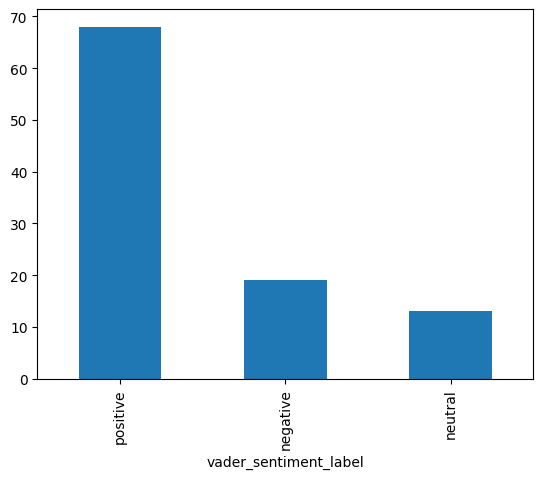

In [18]:
data["vader_sentiment_label"].value_counts().plot.bar()

In [19]:
# Using pretrained transformer models for sentiment analysis
transformer_pipeline = pipeline("sentiment-analysis")



No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[['POSITIVE']]

In [21]:
# REDUNDANT. LENGTHY APPROACH
transformer_label = []

def transform(review):
  sentiment_list = transformer_pipeline(review)
  print(sentiment_list)
  sentiment_label = [sentiment["label"] for sentiment in sentiment_list]
  transformer_label.append(sentiment_label)

transform(data["cleaned_reviewText"][0])
transformer_label

[{'label': 'POSITIVE', 'score': 0.9985702037811279}]


[['POSITIVE']]

In [22]:
def get_transformer_label(review):
  # The pipeline returns a list of dictionaries, e.g., [{'label': 'POSITIVE', 'score': 0.99...}]
  # We extract the 'label' from the first dictionary.
  result = transformer_pipeline(review)
  return result[0]['label']

data['transformer_label'] = data['cleaned_reviewText'].apply(get_transformer_label)
display(data[['cleaned_reviewText', 'rating', 'vader_sentiment_label', 'transformer_label']].head())

,cleaned_reviewText,rating,vader_sentiment_label,transformer_label
0,clean and funny a bit busy with all the differ...,3,positive,POSITIVE
1,alex a sexy hot cop and the phd candidate what...,4,positive,POSITIVE
2,good thing that this is a free story i read it...,1,positive,NEGATIVE
3,action action action equipment keeps getting b...,4,positive,NEGATIVE
4,this was hands down the worse book i have ever...,1,negative,NEGATIVE


In [23]:
data.transformer_label.value_counts()

,count
transformer_label,
POSITIVE,54
NEGATIVE,46


<Axes: ylabel='transformer_label'>

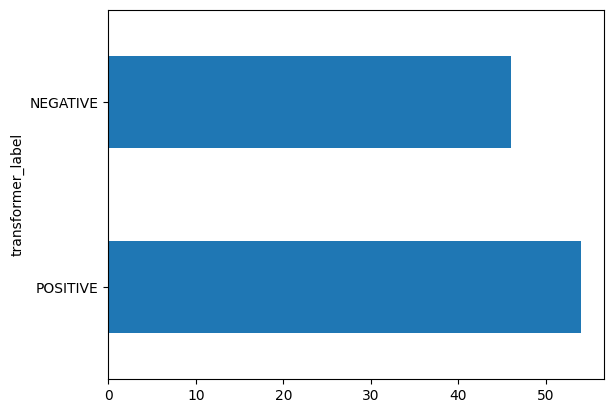

In [28]:
data.transformer_label.value_counts().plot.barh()

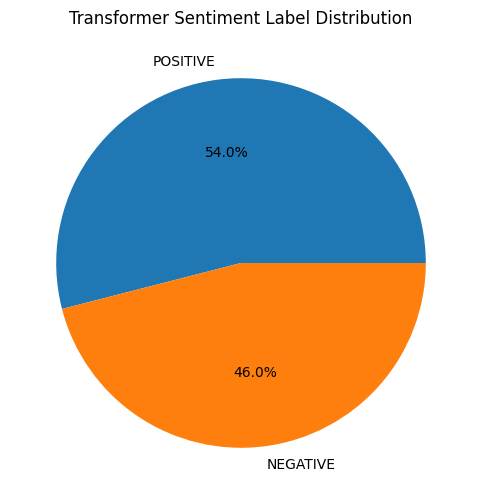

In [29]:
data.transformer_label.value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6))
plt.title('Transformer Sentiment Label Distribution')
plt.ylabel('') # Hide the default y-label as it's not meaningful for pie charts
plt.show()

<Axes: >

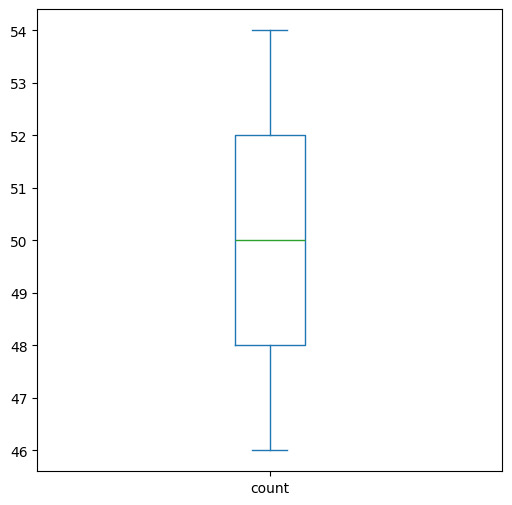

In [39]:
"""
'line' for line plots
'bar' for vertical bar plots
'barh' for horizontal bar plots
'hist' for histograms
'box' for box plots
'kde' or 'density' for density plots
'area' for area plots
'pie' for pie charts
'scatter' for scatter plots (requires x and y arguments)
"""
data.transformer_label.value_counts().plot.box(figsize=(6,6))